# ・Data Aquisition

### 0.04％per1day, 勝率、プロフィット、損益、カンニングなし,異常値の除去、ドローダウン

##### ↑	OI上昇 ↗	【強い上昇】 新規の買いが入っている。トレンド継続。
##### ↑	OI下落 ↘	【弱い上昇】 ショート勢の逃げ（買い戻し）。一時的な上昇の可能性。
##### ↓	OI上昇 ↗	【強い下落】 新規の売りが攻めてきている。下げ継続
##### ↓	OI下落 ↘	【弱い下落】 ロング勢の敗走。底打ちが近い可能性。

##### ↑　FR- ショートの踏み上げ準備 弱気なショート勢が焼かれている（または利食いしている）だけの、中身の薄い上昇
##### ↑　FR+ 健全な上昇0.05まで

##### ↓　FR- マイナストレンド 0.05まで
##### ↓　FR+ 落ちるナイフ

In [ ]:
import ccxt
import datetime
from dateutil.relativedelta import relativedelta
from finta import TA # fintaからTAをインポート
import pandas as pd
import numpy as np
import mplfinance as mpf
import yfinance as yf

print("aa")

In [ ]:
# data setting
exchange = ccxt.binance()
symbol = 'BTC/USDT'
timeframe_1m = "1m"
timeframe_5m = "5m"
timeframe_15m = "15m"
timeframe_30m = "30m"
timeframe_1h = "1h"
timeframe_2h = "2h"
timeframe_4h = "4h"
timeframe_1d = "1d"
timeframe_1w = "1w"
timeframe_1M = "1M"
#since = exchange.parse8601("2022-01-01T00:00:00Z")  # start date

#limit = 500  # 過去◯日分
style = "yahoo"

import requests
import json

def get_usdjpy_direct():
    url = "https://query1.finance.yahoo.com/v8/finance/chart/JPY=X"
    
    params = {
        "range": "1d",
        "interval": "1m"
    }
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    try:
        # リクエスト送信
        response = requests.get(url, headers=headers, params=params)
        response.raise_for_status() # 403/404エラーなどの場合はここで例外発生
        
        data = response.json()
        
        meta_data = data['chart']['result'][0]['meta']
        current_price = meta_data.get('regularMarketPrice')
        
        if current_price is None:
            quotes = data['chart']['result'][0]['indicators']['quote'][0]['close']
            valid_quotes = [q for q in quotes if q is not None]
            if valid_quotes:
                current_price = valid_quotes[-1]

        return round(current_price, 3) if current_price else None

    except Exception as e:
        print(f"取得エラー詳細: {e}")
        return None

# 実行
if __name__ == "__main__":
    rate = get_usdjpy_direct()
    if rate:
        print(f"現在のドル円レート: 1ドル = {rate} 円")
    else:
        print("レートが取得できませんでした。")

現在のドル円レート: 1ドル = 159.316 円


In [ ]:
# Candle
def set_candle_data(symbol, timeframe, since, limit, title, year):
    if since == 0: 
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    else:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=limit)

    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)
    #df_year = df.loc[year]
    mpf.plot(df, type="candle", style=style, title=f"{title}", volume=True)
    print(df["Close"][-1])

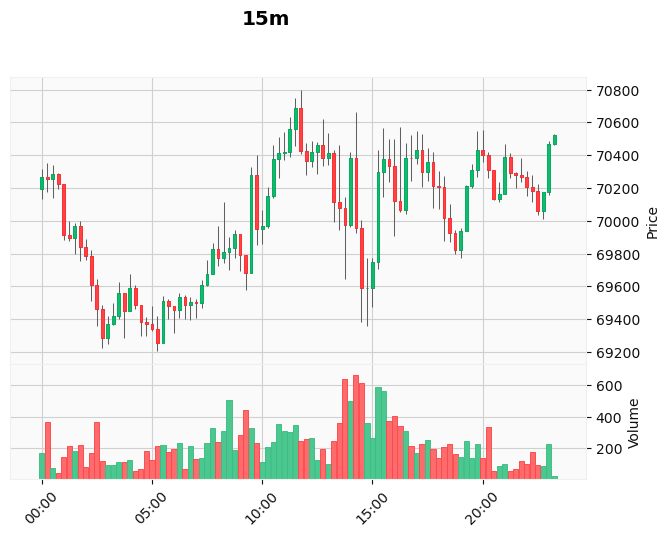

70520.04


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\2900306154.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df["Close"][-1])


In [4]:
today = datetime.date.today()

since = exchange.parse8601(f"{today-datetime.timedelta(1)}T00:00:00Z")
set_candle_data(symbol, timeframe_15m, since, 3000, "15m", "2025")

# ・Moving Average

In [5]:
# Moving Averagne
def set_data_ma(symbol, timeframe, since, limit, title, mav):
    if since == 0: 
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
    else:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=limit)

    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)

    mpf.plot(df, type="candle", style=style, title=f"({title})", volume=True, mav=mav)

# ・Moving Average Convergence Divergence

In [6]:
# MACD
def set_data_macd(symbol, timeframe, l, month):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    df_current_daily = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df_current_daily["Timestamp"] = pd.to_datetime(df_current_daily["Timestamp"], unit="ms")
    df_current_daily.set_index("Timestamp", inplace=True)

    # --- 2. finta のために列名を小文字に変更 ---
    # fintaは 'open', 'high', 'low', 'close' を要求します
    df_current_daily.rename(columns={
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Volume': 'volume'
    }, inplace=True)


    # --- 3. finta で MACD を計算 ---
    print("finta で MACD (12, 26, 9) を計算します...")
    # fintaのTA.MACDを呼び出す
    # fintaは計算結果のDataFrameを返します
    macd_df = TA.MACD(df_current_daily, period_fast=12, period_slow=26, signal=9)

    # 元のDataFrameに計算結果を結合（マージ）する
    df_current_daily = pd.concat([df_current_daily, macd_df], axis=1)
    df_current_daily['HISTOGRAM'] = df_current_daily['MACD'] - df_current_daily['SIGNAL']

    # --- 4. 直近3ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=month)
    df_last_3m = df_current_daily.loc[three_months_ago:].copy()

    # --- 5. MACDプロットの準備 ---
    # fintaが追加した列名 (MACD, SIGNAL, HISTOGRAM)
    macd_col = 'MACD'    # MACDライン
    signal_col = 'SIGNAL'  # シグナルライン
    hist_col = 'HISTOGRAM' # ヒストグラム

    # ヒストグラムの色分け (前回と同様)
    df_last_3m['hist_pos'] = df_last_3m[hist_col].apply(lambda x: x if x >= 0 else 0)
    df_last_3m['hist_neg'] = df_last_3m[hist_col].apply(lambda x: x if x < 0 else 0)

    # サブパネル(panel=2)にMACDを描画する設定 (前回とほぼ同じ)
    ap_macd = [
        mpf.make_addplot(df_last_3m[macd_col], panel=2, color='blue', ylabel='MACD'),
        mpf.make_addplot(df_last_3m[signal_col], panel=2, color='orange'),
        mpf.make_addplot(df_last_3m['hist_pos'], type='bar', panel=2, color='green', alpha=0.7),
        mpf.make_addplot(df_last_3m['hist_neg'], type='bar', panel=2, color='red', alpha=0.7)
    ]

    # --- 6. プロット実行 ---
    print("fintaで計算したMACDを描画します...")
    mpf.plot(df_last_3m, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (finta MACD)',
             volume=True,
             mav=(10, 25), 
             addplot=ap_macd,
             panel_ratios=(3, 1, 2)
            )

# ・Bollinger Bands

In [7]:
# Bollinger Bands
def set_data_bb(symbol, timeframe, l, month):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    df_current_daily = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df_current_daily["Timestamp"] = pd.to_datetime(df_current_daily["Timestamp"], unit="ms")
    df_current_daily.set_index("Timestamp", inplace=True)

    # finta のために列名を小文字に変更
    df_current_daily.rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low',
        'Close': 'close', 'Volume': 'volume'
    }, inplace=True)

    # 2b. ボリンジャーバンド (標準設定: 20期間, 標準偏差2)
    print("finta で ボリンジャーバンド (20, 2) を計算します...")
    # TA.BBANDS を呼び出す
    bbands_df = TA.BBANDS(df_current_daily, period=20)
    # 元のDataFrameに結合 ('BB_UPPER', 'BB_MIDDLE', 'BB_LOWER' が追加される)
    df_current_daily = pd.concat([df_current_daily, bbands_df], axis=1)


    # --- 3. 直近3ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=month)
    df_last_3m = df_current_daily.loc[three_months_ago:].copy()


    # --- 4. プロットの準備 ---

    # 4b. ボリンジャーバンドの準備 (panel=0, メインチャートに重ねる)
    ap_bbands = [
        # アッパーバンド (細い線)
        mpf.make_addplot(df_last_3m['BB_UPPER'], panel=0, color='cyan', width=0.7),
        # ロワーバンド (細い線)
        mpf.make_addplot(df_last_3m['BB_LOWER'], panel=0, color='cyan', width=0.7),
        # ミドルバンド (SMA20, 点線)
        mpf.make_addplot(df_last_3m['BB_MIDDLE'], panel=0, color='grey', linestyle='--', width=0.7)
    ]

    # 4c. 2つのプロットリストを結合
    all_addplots = ap_bbands


    # --- 5. プロット実行 ---
    print("BBandsとMACDを追加して描画します...")

    mpf.plot(df_last_3m, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (Bollinger Bands & MACD)',
             volume=True,

             # 短期SMA (mav) も一緒に表示 (不要ならこの行を消す)
             mav=(10, 25), 

             # ボリンジャーバンド(panel=0)
             addplot=all_addplots,

             # パネルの比率 (メイン: 3, Volume: 1)
             panel_ratios=(3, 1)
            )

# ・RSI

In [8]:
def set_data_rsi(symbol, timeframe, l, month):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    # --- 2. DataFrameの準備 ---
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    # (重要!) タイムスタンプをインデックスに設定
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)

    # finta のために列名を小文字に変更
    df.rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low',
        'Close': 'close', 'Volume': 'volume'
    }, inplace=True)

    # --- 3. finta で RSI を計算 ---
    print(f"finta で RSI (14) を計算します...")
    df['RSI'] = TA.RSI(df, period=14)

    # --- 4. 直近3ヶ月分をスライス ---
    # （fintaの計算後にスライスするのが確実です）
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=month)
    df_plot = df.loc[three_months_ago:].copy()

    # --- 5. プロットの準備 (RSIパネル) ---
    # 70と30の水平線用の列を追加
    df_plot['rsi_70'] = 70
    df_plot['rsi_50'] = 50
    df_plot['rsi_30'] = 30

    # メイン(panel=0)の下、最初のサブパネル(panel=1)に描画
    ap_rsi = [
        # 1. RSI本体 (これが左側の主軸 "primary" Y-axis を作る)
        mpf.make_addplot(df_plot['RSI'], panel=1, color='purple', ylabel='RSI'),

        # 2. 70のライン (赤色の点線)
        # secondary_y=False を指定し、右側に軸を作らせず、左側の主軸を使うよう強制
        mpf.make_addplot(df_plot['rsi_70'], panel=1, color='red', linestyle='--', width=0.7, secondary_y=False),

        # 2. 50のライン (黒の点線)
        # secondary_y=False を指定し、右側に軸を作らせず、左側の主軸を使うよう強制
        mpf.make_addplot(df_plot['rsi_50'], panel=1, color='black', linestyle='--', width=0.7, secondary_y=False),

        # 4. 30のライン (緑色の点線)
        # secondary_y=False を指定し、右側に軸を作らせず、左側の主軸を使うよう強制
        mpf.make_addplot(df_plot['rsi_30'], panel=1, color='green', linestyle='--', width=0.7, secondary_y=False)
    ]

    # --- 6. プロット実行 (シンプル版) ---
    print("RSI を追加して描画します...")

    mpf.plot(df_plot, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (RSI only)',
             # addplotにRSIを指定
             addplot=ap_rsi,

            )

# ・Fibonacci Retracement(Up Trande)

In [9]:
 def set_data_ufr(symbol, timeframe, l, m):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)
    df.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'}, inplace=True)

    # --- 2. 直近3ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=m)
    df_plot = df.loc[three_months_ago:].copy()

    # --- 3. フィボナッチ・リトレースメントの計算 ---
    print("フィボナッチ・リトレースメントを計算します...")

    # 1. 期間内の最高値と最安値を取得
    period_high = df_plot['high'].max()
    period_low = df_plot['low'].min()
    period_range = period_high - period_low

    print(f"  期間高値: {period_high}")
    print(f"  期間安値: {period_low}")

    # 2. 各レベルの価格を計算 (上昇トレンドを仮定)
    # (高値 = 100%, 安値 = 0%)
    fib_level_0_0 = period_high # 100% (高値)
    fib_level_23_6 = period_high - (period_range * 0.236)
    fib_level_38_2 = period_high - (period_range * 0.382)
    fib_level_50_0 = period_high - (period_range * 0.500) # 半値
    fib_level_61_8 = period_high - (period_range * 0.618)
    fib_level_100_0 = period_low  # 0% (安値)

    # 3. mplfinance で描画するための水平線リストを作成
    fib_lines = [
        fib_level_0_0, fib_level_23_6, fib_level_38_2, 
        fib_level_50_0, fib_level_61_8, fib_level_100_0
    ]
    fib_colors = ['gray', 'orange', 'blue', 'green', 'blue', 'gray']
    fib_styles = ['--', ':', ':', ':', ':', '--']

    # --- 4. プロット実行 ---
    print("フィボナッチラインを描画します...")

    mpf.plot(df_plot, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (Fibonacci Retracement)',

             # hlines (水平線) としてフィボナッチレベルを描画
             hlines=dict(hlines=fib_lines, 
                         colors=fib_colors, 
                         linestyle=fib_styles, 
                         alpha=0.7)
            )

# ・Fibonacci Retracement(Down Trande)

In [10]:
def set_dat_df(symbol, timeframe, l, m, yen):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)
    df.rename(columns={'Open': 'open', 'High': 'high', 'Low': 'low', 'Close': 'close'}, inplace=True)

    # --- 2. 直近3ヶ月分をスライス (変更なし) ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=m)
    df_plot = df.loc[three_months_ago:].copy()

    # --- 3. フィボナッチ・リトレースメントの計算 (下降トレンド用) ---

    # 1. 期間内の最高値と最安値を取得
    period_high = df_plot['high'].max()
    period_low = df_plot['low'].min()
    period_range = period_high - period_low

    print(f"  期間高値 (100%): ￥{period_high * yen}")
    print(f"  期間安値 (  0%): ￥{period_low * yen}")

    # 2. 各レベルの価格を計算 (最安値に足していく)
    fib_level_0_0 = period_low     # 0% (安値)
    fib_level_23_6 = period_low + (period_range * 0.236)
    fib_level_38_2 = period_low + (period_range * 0.382)
    fib_level_50_0 = period_low + (period_range * 0.500) # 半値
    fib_level_61_8 = period_low + (period_range * 0.618)
    fib_level_100_0 = period_high # 100% (高値)

    # 3. mplfinance で描画するための水平線リストを作成
    fib_lines = [
        fib_level_0_0, fib_level_23_6, fib_level_38_2, 
        fib_level_50_0, fib_level_61_8, fib_level_100_0
    ]
    fib_colors = ['gray', 'orange', 'blue', 'green', 'blue', 'gray']
    fib_styles = ['--', ':', ':', ':', ':', '--']
    
    print(f"fib23.6% : ￥{fib_level_23_6 * yen}")
    print(f"fib38.2% : ￥{fib_level_38_2 * yen}")
    print(f"fib50% 　: ￥{fib_level_50_0 * yen}")
    print(f"fib61.8% : ￥{fib_level_61_8 * yen}")

    # --- 4. プロット実行 (変更なし) ---

    mpf.plot(df_plot, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (Fibonacci Retracement - Downtrend)',

             # hlines (水平線) としてフィボナッチレベルを描画
             hlines=dict(hlines=fib_lines, 
                         colors=fib_colors, 
                         linestyle=fib_styles, 
                         alpha=0.7)
            )

# ・ストキャスティクス

In [11]:
def set_data_st(symbol, timeframe, l ,m):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    if not ohlcv:
        print("データが取得できませんでした。")
        exit()

    # --- 2. DataFrameの準備 ---
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)

    # finta のために列名を小文字に変更
    df.rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low',
        'Close': 'close', 'Volume': 'volume'
    }, inplace=True)

    # --- 3. finta で スロー・ストキャスティクス (14, 3, 3) を計算 ---
    print("finta で スロー・ストキャスティクス (14, 3, 3) を計算します...")

    # 1. Fast %K (14) を計算
    fast_k = TA.STOCH(df, period=14)

    # 2. Slow %K ( = Fast %K の 3期間SMA)
    df['slow_k'] = fast_k.rolling(window=3).mean()
    df['slow_d'] = df['slow_k'].rolling(window=3).mean()
    print(df['slow_k'][-1])
    # --- 4. 直近3ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=m)
    df_plot = df.loc[three_months_ago:].copy()
    
    #today = datetime.datetime.now() - relativedelta(months=36)
    #three_months_ago = today - relativedelta(months=m)
    #df_plot = df.loc[three_months_ago:today].copy()

    # --- 5. プロットの準備 (ストキャスティクスパネル) ---
    # 80と20の水平線用の列を追加
    df_plot['stoch_80'] = 80
    df_plot['stoch_20'] = 20

    # メイン(panel=0)の下、最初のサブパネル(panel=1)に描画
    ap_stoch = [
        # 1. Slow %K (主線, 青)
        mpf.make_addplot(df_plot['slow_k'], panel=1, color='blue', ylabel='Stochastic (14,3,3)'),

        # 2. Slow %D (シグナル線, オレンジ)
        mpf.make_addplot(df_plot['slow_d'], panel=1, color='orange', linestyle='--'),

        # 3. 80のライン (赤色の点線)
        # secondary_y=False で左軸を強制的に共有 (RSIの時と同じ)
        mpf.make_addplot(df_plot['stoch_80'], panel=1, color='red', linestyle='--', width=0.7, secondary_y=False),

        # 4. 20のライン (緑色の点線)
        mpf.make_addplot(df_plot['stoch_20'], panel=1, color='green', linestyle='--', width=0.7, secondary_y=False)
    ]

    # --- 6. プロット実行 (シンプル版) ---
    print("ストキャスティクスを追加して描画します...")

    mpf.plot(df_plot, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (Stochastic)',

             # addplotにストキャスティクスを指定
             addplot=ap_stoch

             # 軸の混乱を避けるため、volume=True と panel_ratios を削除
            )

# ・ATR

In [12]:
def set_data_atr(symbol, timeframe, l, m):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    if not ohlcv:
        print("データが取得できませんでした。")
        exit()

    # --- 2. DataFrameの準備 ---
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)

    # finta のために列名を小文字に変更
    df.rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low',
        'Close': 'close', 'Volume': 'volume'
    }, inplace=True)

    # --- 3. finta で ATR (14) を計算 ---
    print("finta で ATR (14) を計算します...")
    # TA.ATR は "Average True Range" という列名でDataFrameを返す
    atr_df = TA.ATR(df, period=14)
    # 元のDataFrameに 'ATR' という名前で結合
    df['ATR'] = TA.ATR(df, period=14)


    # --- 4. 直近3ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=m)
    df_plot = df.loc[three_months_ago:].copy()

    # --- 5. プロットの準備 (ATRパネル) ---
    # ATRは価格の単位 (ドルなど) を持つため、独自のY軸を使います
    ap_atr = [
        # 1. ATR本体
        mpf.make_addplot(df_plot['ATR'], panel=1, color='blue', ylabel='ATR (14)'),
    ]

    # --- 6. プロット実行 (シンプル版) ---
    print("ATR を追加して描画します...")

    mpf.plot(df_plot, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (ATR)',

             # addplotにATRを指定
             addplot=ap_atr

             # 軸の混乱を避けるため、volume=True と panel_ratios を削除
            )

# ・OBV

In [13]:
 def set_data_obv(symbol, timeframe, l, m):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    if not ohlcv:
        print("データが取得できませんでした。")
        exit()

    # --- 2. DataFrameの準備 ---
    df = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="ms")
    df.set_index("Timestamp", inplace=True)

    # finta のために列名を小文字に変更
    df.rename(columns={
        'Open': 'open', 'High': 'high', 'Low': 'low',
        'Close': 'close', 'Volume': 'volume' # OBVのために 'volume' を残す
    }, inplace=True)

    # --- 3. finta で OBV を計算 ---
    print("finta で OBV を計算します...")
    # TA.OBV は OBV の計算結果 (Series) を直接返します
    df['OBV'] = TA.OBV(df)


    # --- 4. 直近3ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=m)
    df_plot = df.loc[three_months_ago:].copy()

    # --- 5. プロットの準備 (OBVパネル) ---
    # OBVは独自のY軸を使います
    ap_obv = [
        # 1. OBV本体
        mpf.make_addplot(df_plot['OBV'], panel=1, color='green', ylabel='OBV'),
    ]

    # --- 6. プロット実行 (シンプル版) ---
    print("OBV を追加して描画します...")

    mpf.plot(df_plot, 
             type='candle', 
             style='yahoo',
             title='BTC/USDT Daily (OBV)',

             # addplotにOBVを指定
             addplot=ap_obv

             # 軸の混乱を避けるため、volume=True と panel_ratios を削除
            )

# ・VWAP

In [14]:
#import ccxt
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt

# 1. データ取得
#exchange = ccxt.binance()
#symbol = 'BTC/USDT'
#timeframe = '15m'
#limit = 1000  # 約10日分

#ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=limit)
#df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
#df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
#df.set_index('timestamp', inplace=True)

# 2. 【重要】VWAPを「1日ごとに」計算するロジック
# Fintaを使わず、Pandasで直接計算してリセットをかけます

def calculate_daily_vwap(df):
    df_vwap = df.copy()
    # 代表値 (Typical Price)
    df_vwap['tp'] = (df['high'] + df['low'] + df['close']) / 3
    df_vwap['tp_vol'] = df_vwap['tp'] * df['volume']
    
    # 日付ごとにグループ化して累積和 (cumsum) をとる
    # これにより毎日 00:00 (UTC) に計算がリセットされます
    grouper = df_vwap.groupby(df_vwap.index.date)
    df_vwap['cum_tp_vol'] = grouper['tp_vol'].cumsum()
    df_vwap['cum_vol'] = grouper['volume'].cumsum()
    
    return df_vwap['cum_tp_vol'] / df_vwap['cum_vol']

#df['VWAP_Daily'] = calculate_daily_vwap(df)

# 3. グラフ描画
#plt.figure(figsize=(14, 8))

# 価格
#plt.plot(df.index, df['close'], label='Price', color='gray', alpha=0.6)

# 日次リセットVWAP
#plt.plot(df.index, df['VWAP_Daily'], label='Session VWAP (Daily Reset)', color='orange', linewidth=2)

#plt.title(f'{symbol} Session VWAP (Resets Daily)')
#plt.legend()
#plt.grid(True, alpha=0.3)
#plt.show()

# SAR

In [15]:
def set_data_sar(symbol, timeframe, l, month):
    # --- 1. データ取得 ---
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    df_current_daily = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df_current_daily["Timestamp"] = pd.to_datetime(df_current_daily["Timestamp"], unit="ms")
    df_current_daily.set_index("Timestamp", inplace=True)

    # --- 2. finta のために列名を小文字に変更 ---
    df_current_daily.rename(columns={
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Volume': 'volume'
    }, inplace=True)

    # --- 3. finta で Parabolic SAR を計算 (修正箇所) ---
    print("finta で Parabolic SAR を計算します...")
    
    # 一度計算結果を変数に受け取ります（ここで3列のデータが返ってきます）
    psar_df = TA.PSAR(df_current_daily)
    
    # 結果の中から 'psar' という列だけを取り出して、元のdfに追加します
    df_current_daily['PSAR'] = psar_df['psar']

    # --- 4. 直近指定ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=month)
    df_last_3m = df_current_daily.loc[three_months_ago:].copy()

    # --- 5. SARプロットの準備 ---
    ap_sar = [
        mpf.make_addplot(df_last_3m['PSAR'], type='scatter', panel=0, markersize=50, color='blue', marker='.')
    ]

    # --- 6. プロット実行 ---
    print("fintaで計算したSARを描画します...")
    mpf.plot(df_last_3m, 
             type='candle', 
             style='yahoo',
             title=f'{symbol} Daily (finta Parabolic SAR)',
             volume=True,
             mav=(10, 25), 
             addplot=ap_sar,
             panel_ratios=(3, 1)
            )

# ADX

In [16]:
def set_data_adx(symbol, timeframe, l, month):
    # --- 1. データ取得 ---
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe, limit=l)

    df_current_daily = pd.DataFrame(ohlcv, columns=["Timestamp", "Open", "High", "Low", "Close", "Volume"])
    df_current_daily["Timestamp"] = pd.to_datetime(df_current_daily["Timestamp"], unit="ms")
    df_current_daily.set_index("Timestamp", inplace=True)

    # --- 2. finta のために列名を小文字に変更 ---
    df_current_daily.rename(columns={
        'Open': 'open',
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Volume': 'volume'
    }, inplace=True)

    # --- 3. finta で ADX, +DI, -DI を計算 (修正箇所) ---
    print("finta で ADX/DMI (14) を計算します...")
    
    # ADX: トレンドの強さ（これは動くはずです）
    df_current_daily['ADX'] = TA.ADX(df_current_daily, period=14)
    
    # DMI: +DI と -DI をまとめて計算
    # finta の TA.DMI は DataFrame を返します (列名は通常 'DI+' と 'DI-')
    dmi_df = TA.DMI(df_current_daily, period=14)
    
    # デバッグ用に列名を表示（もしエラーが出たらここを確認するため）
    print("DMI columns:", dmi_df.columns)
    
    # 列を取り出してメインのデータフレームに追加
    # ※もし 'DI+' でエラーになる場合は、上のprint結果を見て列名を修正してください
    df_current_daily['PDI'] = dmi_df['DI+']
    df_current_daily['MDI'] = dmi_df['DI-']

    # --- 4. 直近指定ヶ月分をスライス ---
    today = datetime.datetime.now()
    three_months_ago = today - relativedelta(months=month)
    df_last_3m = df_current_daily.loc[three_months_ago:].copy()

    # --- 5. ADXプロットの準備 ---
    
    # 基準線（25ライン）
    line_25 = [25] * len(df_last_3m)

    ap_adx = [
        # ADXライン: 太めの線、マゼンタ色
        mpf.make_addplot(df_last_3m['ADX'], panel=2, color='magenta', width=1.5, ylabel='ADX/DMI'),
        
        # +DI: 青色
        mpf.make_addplot(df_last_3m['PDI'], panel=2, color='blue', width=0.8),
        
        # -DI: 赤色
        mpf.make_addplot(df_last_3m['MDI'], panel=2, color='red', width=0.8),
        
        # 基準線: 点線、グレー
        mpf.make_addplot(line_25, panel=2, color='gray', linestyle='dashed', width=0.8)
    ]

    # --- 6. プロット実行 ---
    print("fintaで計算したADXを描画します...")
    mpf.plot(df_last_3m, 
             type='candle', 
             style='yahoo',
             title=f'{symbol} Daily (finta ADX/DMI)',
             volume=True,
             mav=(10, 25), 
             addplot=ap_adx,
             panel_ratios=(3, 1, 2)
            )
#'''    
# エントリー条件】
# ADX（マゼンタ）が25を超えている（トレンドがある！）
# +DI（青）が -DI（赤）より上にある（そのトレンドは上昇だ！）
# この状態で、パラボリックSARがローソク足の下に点灯した 👉 強い買いシグナル（ダマシの可能性が低い）
# 見送り（様子見）条件】
# ADX（マゼンタ）が20〜25以下で低迷している 👉 パラボリックSARのシグナルが出ても無視します。レンジ相場で往復ビンタを食らうのを防げます。
#'''

In [17]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ---------------------------------------------------------
# 設定項目
# ---------------------------------------------------------
 

def fetch_order_book(symbol, limit):
    """Binanceから板情報を取得する"""
    url = "https://api.binance.com/api/v3/depth"
    params = {"symbol": symbol, "limit": limit}
    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        return response.json()
    except Exception as e:
        print(f"データ取得エラー: {e}")
        return None

def process_data(data, bin_size):
    """データを加工・集計する"""
    df_bids = pd.DataFrame(data['bids'], columns=['price', 'quantity'], dtype=float)
    df_asks = pd.DataFrame(data['asks'], columns=['price', 'quantity'], dtype=float)
    df_bids['side'] = 'Buy (Bid)'
    df_asks['side'] = 'Sell (Ask)'
    
    df = pd.concat([df_bids, df_asks])
    df['price_bin'] = (df['price'] // bin_size) * bin_size
    df_grouped = df.groupby(['side', 'price_bin'])['quantity'].sum().reset_index()
    
    return df_grouped

def plot_heatmap_style_depth(df, current_price):
    """グラフを描画する"""
    
    # 1. 表示範囲のフィルタリング
    min_price = current_price * (1 - RANGE_PERCENT)
    max_price = current_price * (1 + RANGE_PERCENT)
    df_filtered = df[(df['price_bin'] >= min_price) & (df['price_bin'] <= max_price)].copy()

    # 2. 【修正箇所】表示順序（order）を「降順（高い順）」に設定
    # Seabornはリストの先頭(0番目)をグラフの「一番上」に描画します。
    # ここで「高い順」に並べることで、
    #  - 画面の一番上： 最高値
    #  - 画面の一番下： 最安値
    # となり、視覚的に「下から上へ価格が上がる」配置になります。
    price_order = sorted(df_filtered['price_bin'].unique(), reverse=True)

    plt.figure(figsize=(12, 10))
    sns.set_style("darkgrid")
    
    # 3. グラフ描画
    ax = sns.barplot(
        data=df_filtered,
        y='price_bin',
        x='quantity',
        hue='side',
        palette={'Sell (Ask)': '#ff4d4d', 'Buy (Bid)': '#00b894'},
        orient='h',
        dodge=False,
        order=price_order  # 降順リストを適用
    )

    # 4. 現在価格ラインの位置計算
    # リストが高い順（High -> Low）なので、
    # 現在価格より「高い」価格帯の数を数えることで、上からの描画位置（インデックス）を特定します。
    higher_bins_count = sum(p > current_price for p in price_order)
    
    # バーの隙間に線を引くため -0.5 で調整
    line_position = higher_bins_count - 0.5
    
    plt.axhline(y=line_position, color='yellow', linestyle='--', linewidth=2, label='Current Price')

    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=30))
    
    # タイトル等を変更
    plt.title(f"{SYMBOL} Order Book (Bottom=Low, Top=High)", fontsize=16)
    plt.xlabel("Volume (BTC)", fontsize=12)
    plt.ylabel("Price (USDT)", fontsize=12)
    plt.legend(title="Side", loc='upper right') 
    plt.tight_layout()
    
    print(f"現在価格: ${current_price:,.2f} 周辺を表示中")
    plt.show()

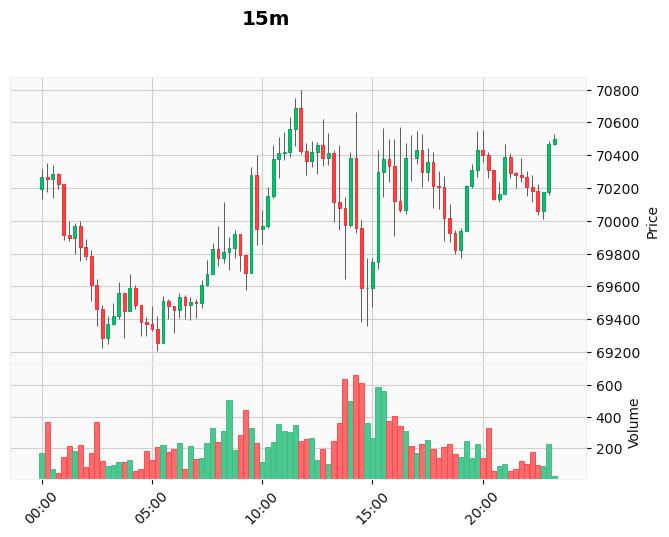

C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\2900306154.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df["Close"][-1])


70501.28


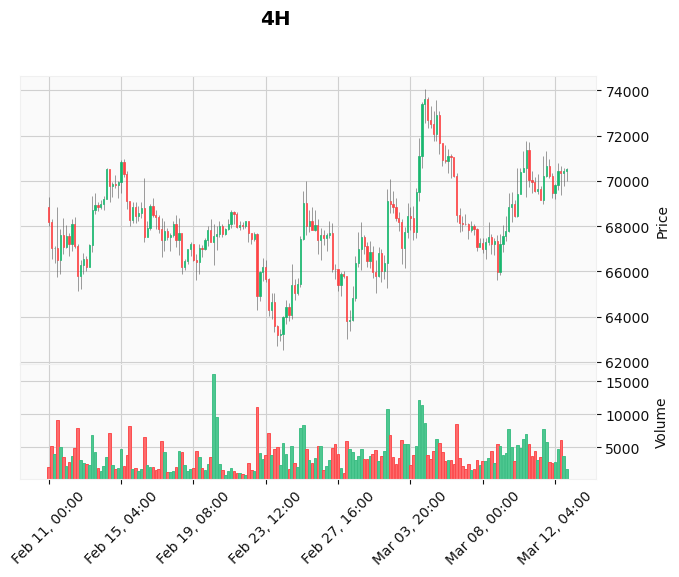

C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\2900306154.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df["Close"][-1])


70508.91


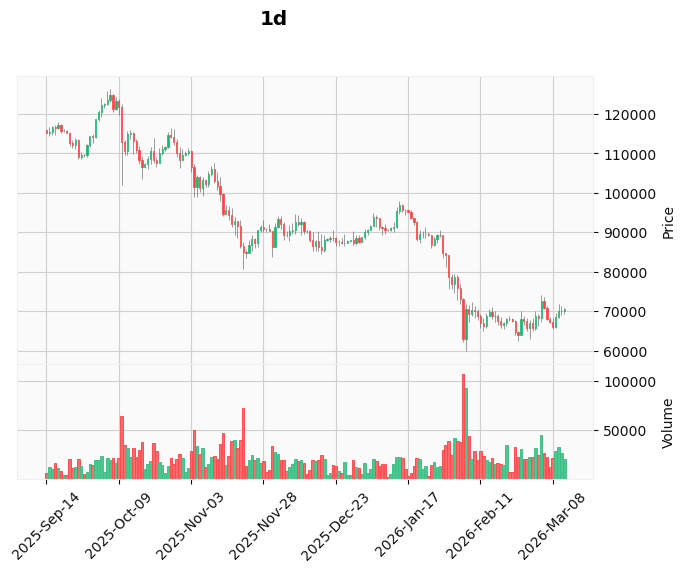

70508.91


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\2900306154.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df["Close"][-1])


In [18]:
today = datetime.date.today()
since = exchange.parse8601(f"{today-datetime.timedelta(1)}T00:00:00Z")
set_candle_data(symbol, timeframe_15m, since, 3000, "15m", "2025")
since = exchange.parse8601(f"{today-datetime.timedelta(30)}T00:00:00Z")
set_candle_data(symbol, timeframe_4h, since, 3000, "4H", "2025")
since = exchange.parse8601(f"{today-datetime.timedelta(180)}T00:00:00Z")
set_candle_data(symbol, timeframe_1d, since, 3000, "1d", "2025")

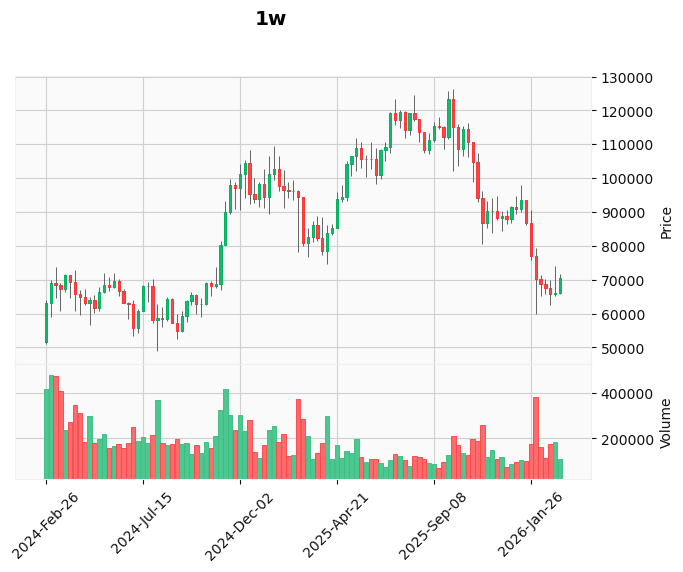

C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\2900306154.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df["Close"][-1])


70513.59


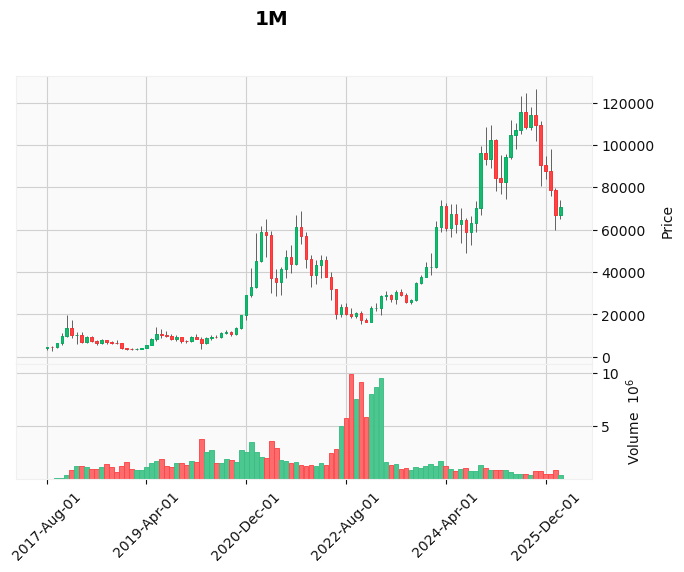

70513.59


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\2900306154.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df["Close"][-1])


In [19]:
since = exchange.parse8601(f"{today-datetime.timedelta(750)}T00:00:00Z")
set_candle_data(symbol, timeframe_1w, since, 3000, "1w", "2025")
since = exchange.parse8601(f"{today-datetime.timedelta(365*9)}T00:00:00Z")
set_candle_data(symbol, timeframe_1M, since, 3000, "1M", "2025")

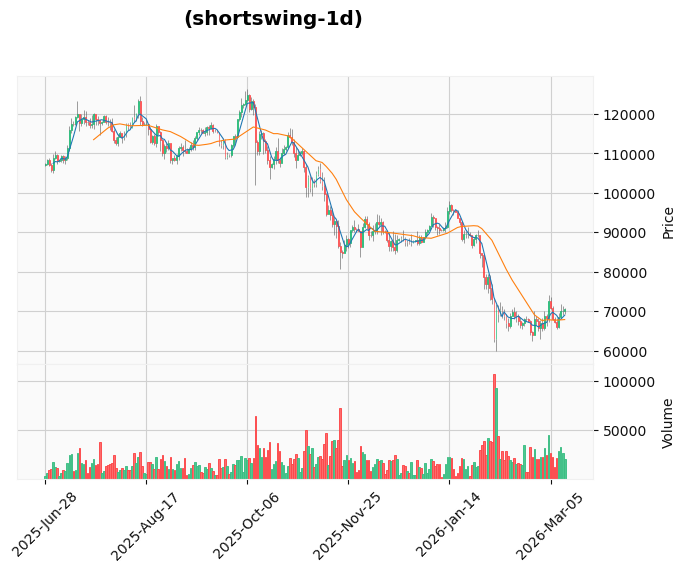

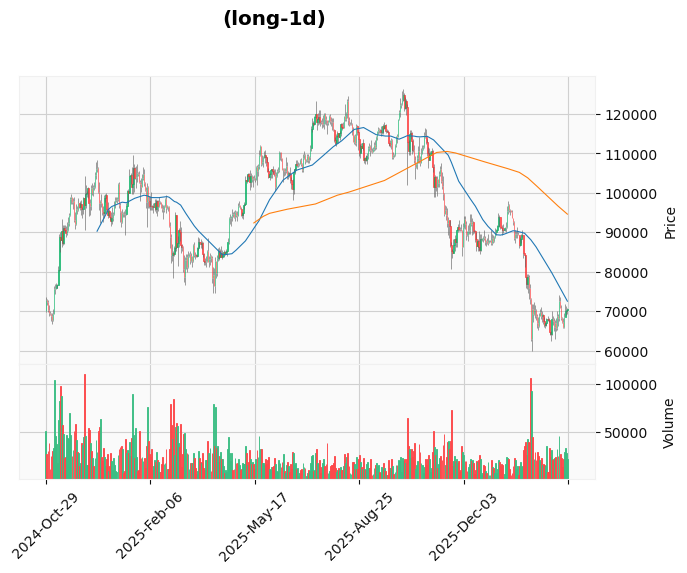

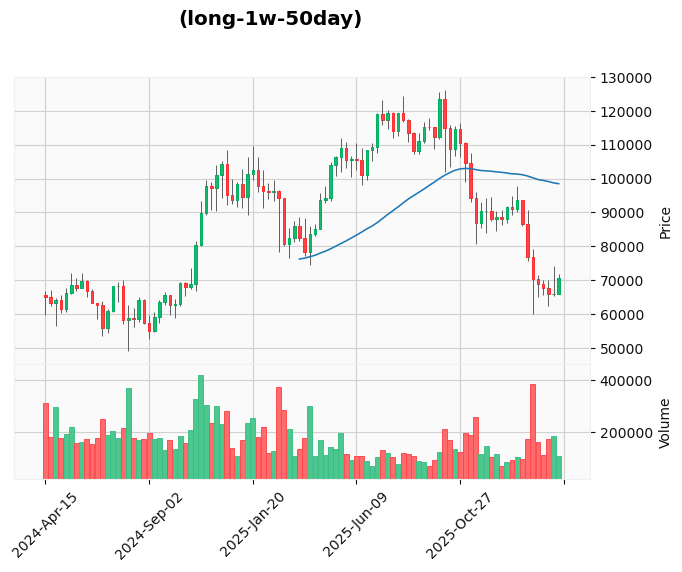

In [20]:
# short ～ long
since = exchange.parse8601("2025-06-28T00:00:00Z")
set_data_ma(symbol, timeframe_1d, since, 2000, "shortswing-1d", (5, 25))  # shortswing(day～week)
#set_data_ma(symbol, timeframe_4h, 0, 200, "short-4h", (12, 60))      # shorttrande（day～week）
#set_data_ma(symbol, timeframe_1d, since, 700, "middle-1d", (25, 75)) # middletrande（week～month）
set_data_ma(symbol, timeframe_1d, 0, 500, "long-1d", (50, 200))      # longtrande(halfmonth～year)
#set_data_ma(symbol, timeframe_1w, 0, 100, "long-1w", (13, 26))      # longtrande（halfweek～year）
set_data_ma(symbol, timeframe_1w, 0, 100, "long-1w-50day", (50))    # 50week Moving Average

finta で MACD (12, 26, 9) を計算します...
fintaで計算したMACDを描画します...


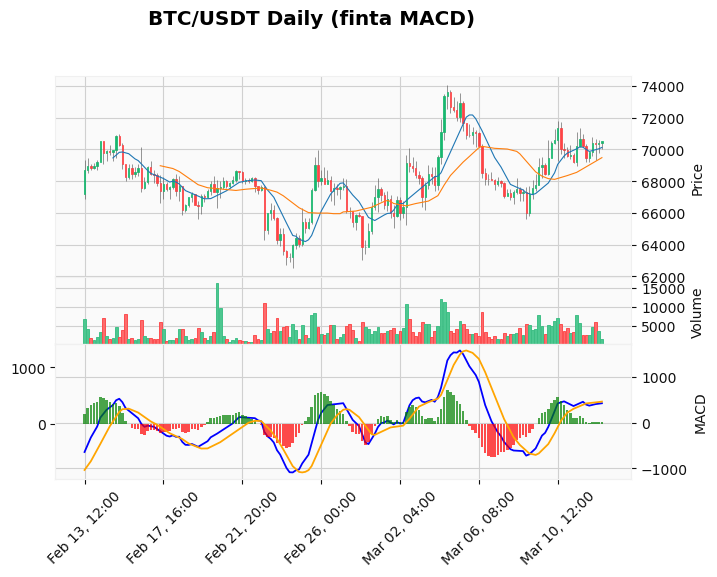

finta で ボリンジャーバンド (20, 2) を計算します...
BBandsとMACDを追加して描画します...


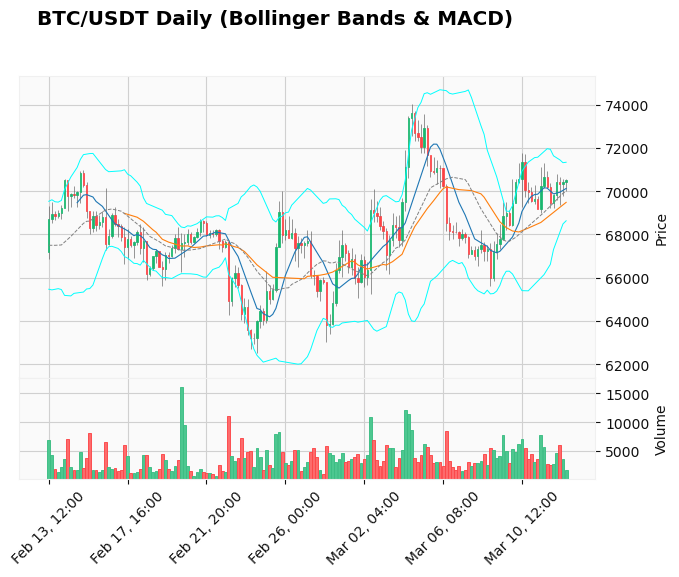

finta で RSI (14) を計算します...
RSI を追加して描画します...


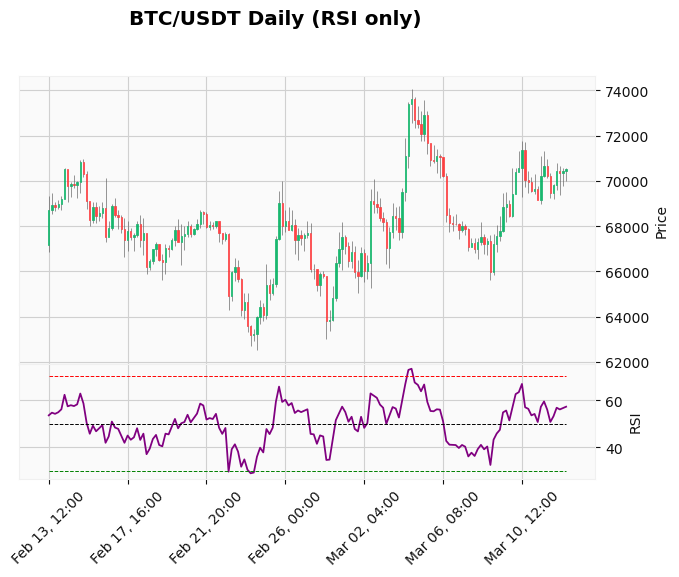

In [21]:
set_data_macd(symbol, timeframe_4h, 2000, 1)
set_data_bb(symbol, timeframe_4h, 2000, 1)
set_data_rsi(symbol, timeframe_4h, 2000, 1)

finta で MACD (12, 26, 9) を計算します...
fintaで計算したMACDを描画します...


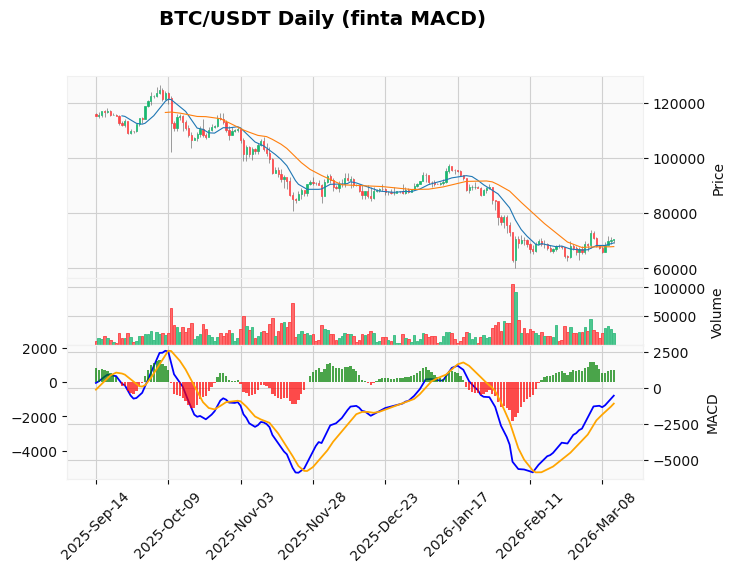

finta で ボリンジャーバンド (20, 2) を計算します...
BBandsとMACDを追加して描画します...


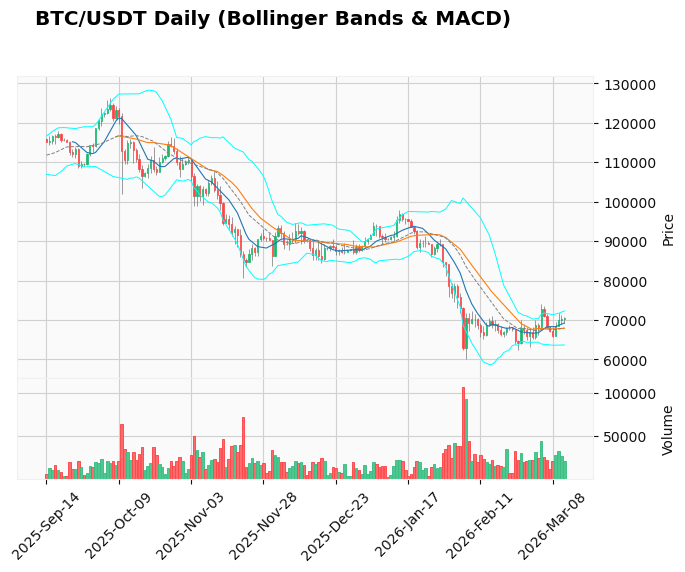

finta で RSI (14) を計算します...
RSI を追加して描画します...


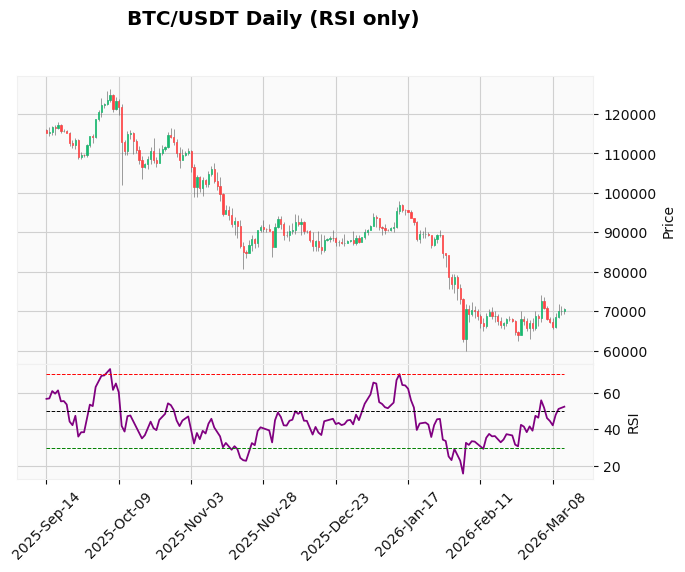

In [22]:
set_data_macd(symbol, timeframe_1d, 2000, 6)
set_data_bb(symbol, timeframe_1d, 2000, 6)
set_data_rsi(symbol, timeframe_1d, 2000, 6)

finta で MACD (12, 26, 9) を計算します...
fintaで計算したMACDを描画します...


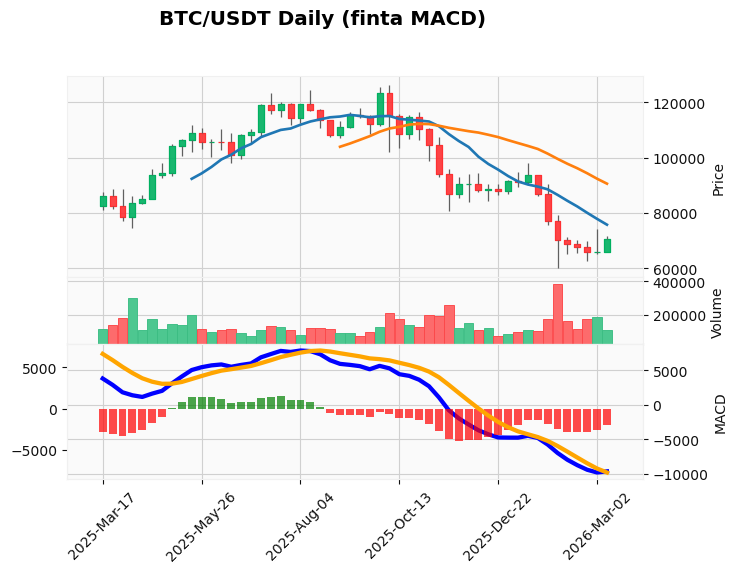

finta で ボリンジャーバンド (20, 2) を計算します...
BBandsとMACDを追加して描画します...


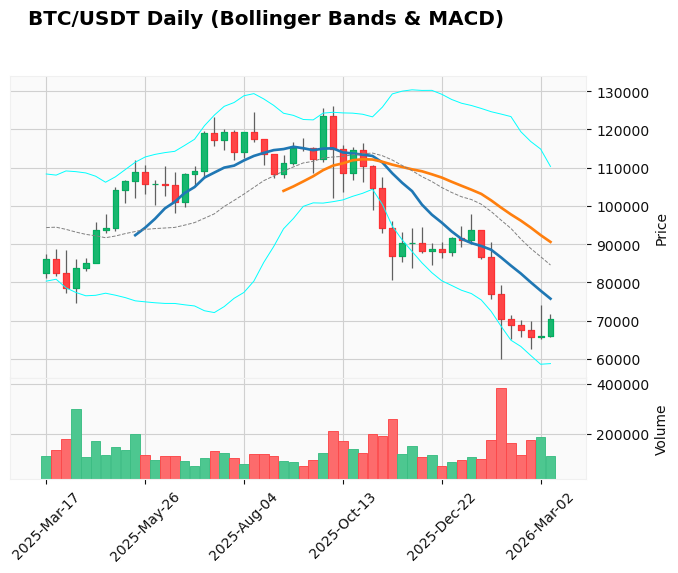

finta で RSI (14) を計算します...
RSI を追加して描画します...


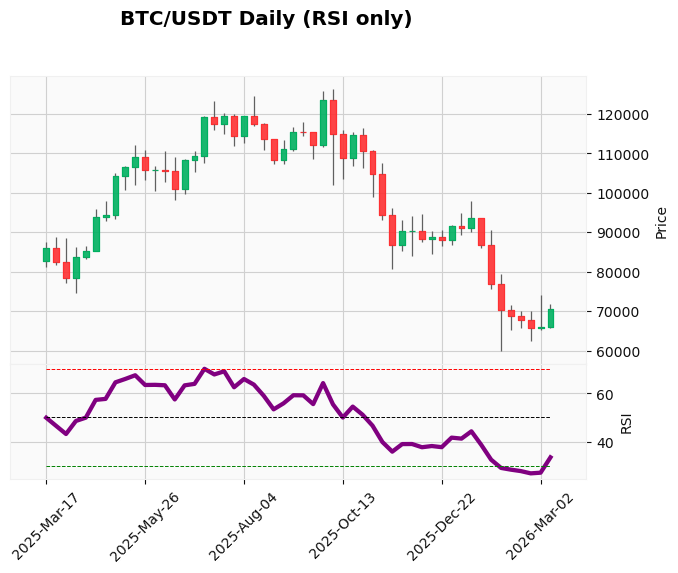

In [23]:
set_data_macd(symbol, timeframe_1w, 2000, 12)
set_data_bb(symbol, timeframe_1w, 2000, 12)
set_data_rsi(symbol, timeframe_1w, 2000, 12)

フィボナッチ・リトレースメントを計算します...
  期間高値: 97924.49
  期間安値: 60000.0
フィボナッチラインを描画します...


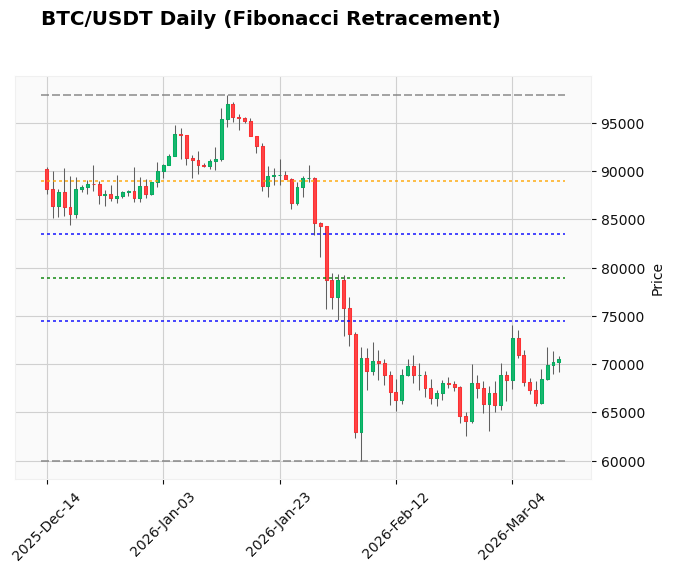

  期間高値 (100%): ￥11477750.0
  期間安値 (  0%): ￥9689093.4
fib23.6% : ￥10111216.3576
fib38.2% : ￥10372360.221199999
fib50% 　: ￥10583421.7
fib61.8% : ￥10794483.178800002


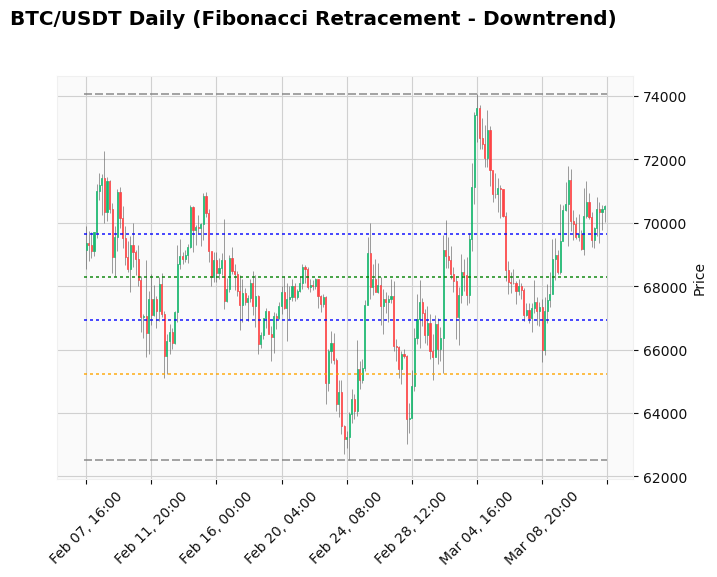

  期間高値 (100%): ￥15178295.950000001
  期間安値 (  0%): ￥9300000.0
fib23.6% : ￥10687277.8442
fib38.2% : ￥11545509.0529
fib50% 　: ￥12239147.975
fib61.8% : ￥12932786.8971


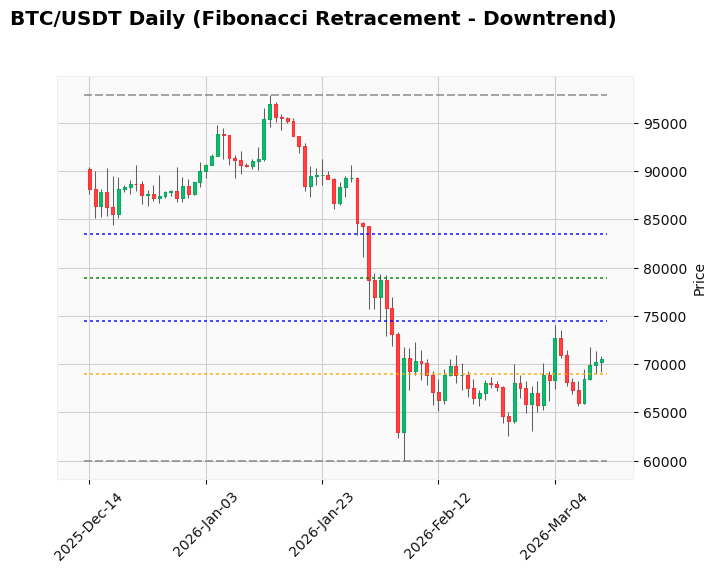

In [24]:
set_data_ufr(symbol, timeframe_1d, 200, 3)
set_dat_df(symbol, timeframe_4h, 200, 3, 155)
set_dat_df(symbol, timeframe_1d, 200, 3, 155)

finta で スロー・ストキャスティクス (14, 3, 3) を計算します...
66.70819893031353
ストキャスティクスを追加して描画します...


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\824163619.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['slow_k'][-1])


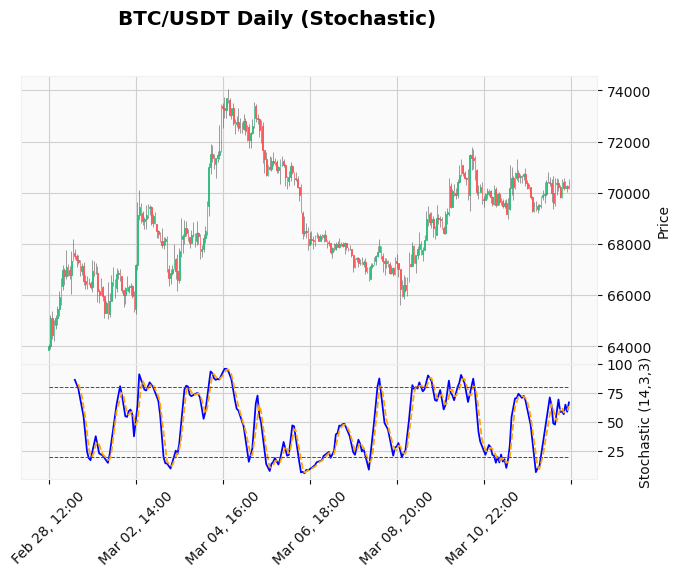

finta で スロー・ストキャスティクス (14, 3, 3) を計算します...
64.61765207104933
ストキャスティクスを追加して描画します...


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\824163619.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['slow_k'][-1])


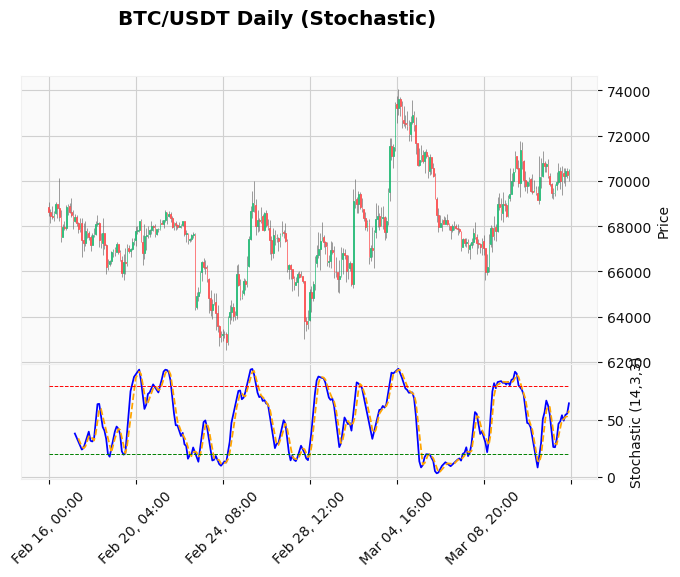

finta で スロー・ストキャスティクス (14, 3, 3) を計算します...
52.2768891442779
ストキャスティクスを追加して描画します...


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\824163619.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['slow_k'][-1])


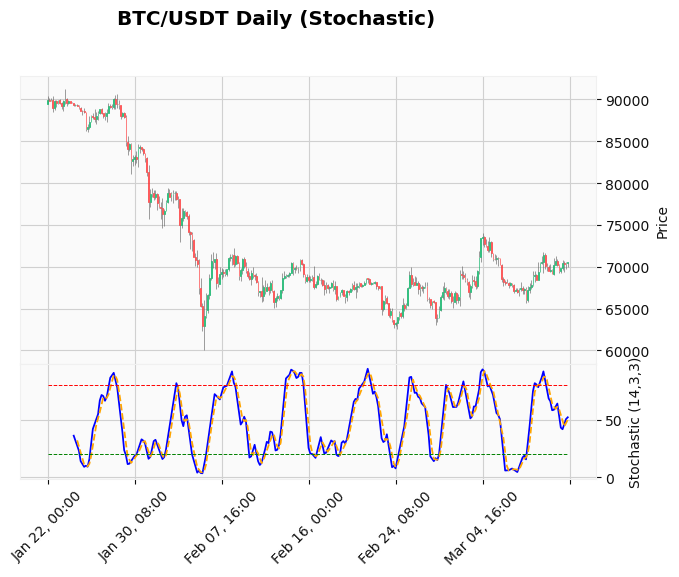

finta で スロー・ストキャスティクス (14, 3, 3) を計算します...
65.22516636418631
ストキャスティクスを追加して描画します...


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\824163619.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['slow_k'][-1])


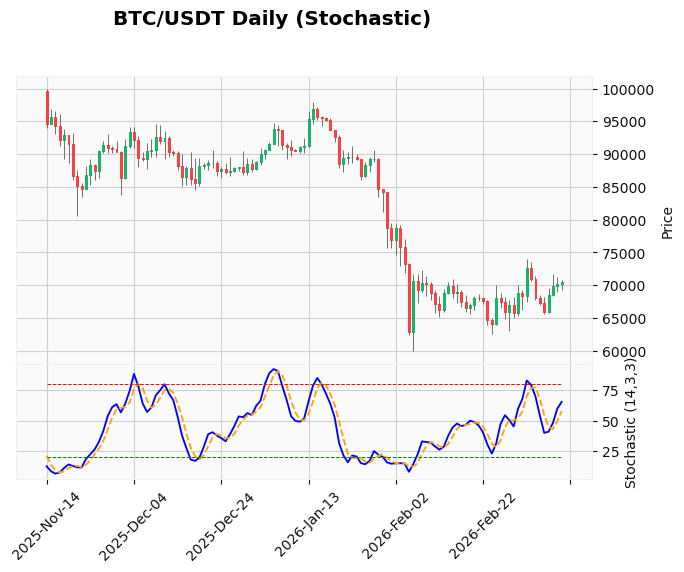

finta で スロー・ストキャスティクス (14, 3, 3) を計算します...
19.56573883173292
ストキャスティクスを追加して描画します...


C:\Users\O-430\AppData\Local\Temp\ipykernel_25928\824163619.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df['slow_k'][-1])


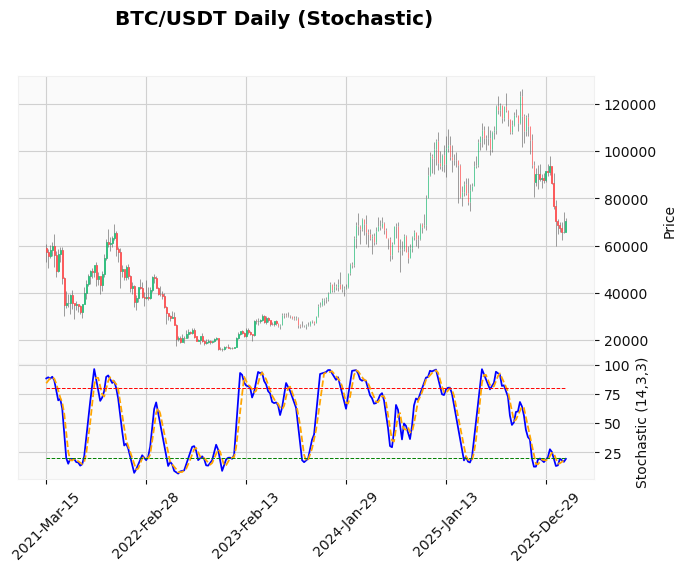

In [25]:
set_data_st(symbol, timeframe_1h, 300, 4)
set_data_st(symbol, timeframe_2h, 300, 4)
set_data_st(symbol, timeframe_4h, 300, 4)
set_data_st(symbol, timeframe_1d, 300, 4)
set_data_st(symbol, timeframe_1w, 2000, 60)

finta で ATR (14) を計算します...
ATR を追加して描画します...


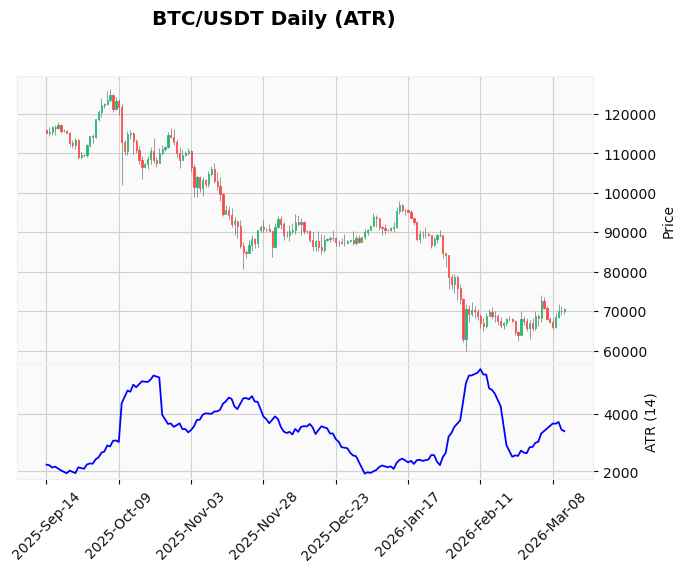

finta で OBV を計算します...
OBV を追加して描画します...


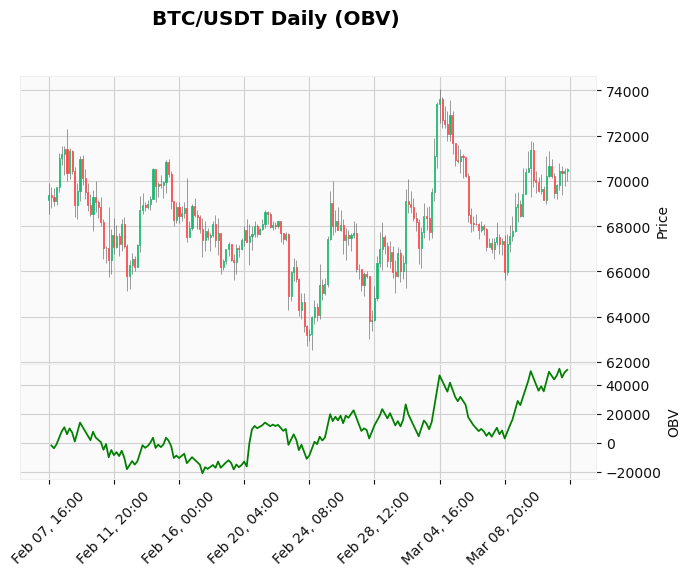

In [26]:
set_data_atr(symbol, timeframe_1d, 200, 6)
set_data_obv(symbol, timeframe_4h, 200, 12)

finta で Parabolic SAR を計算します...
fintaで計算したSARを描画します...


C:\Users\O-430\anaconda3\envs\bot_env\lib\site-packages\finta\finta.py:879: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hp = high[0]
C:\Users\O-430\anaconda3\envs\bot_env\lib\site-packages\finta\finta.py:880: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lp = low[0]
C:\Users\O-430\anaconda3\envs\bot_env\lib\site-packages\finta\finta.py:884: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  psar[i] = psar[i - 1] + af * (hp - psar[i - 1

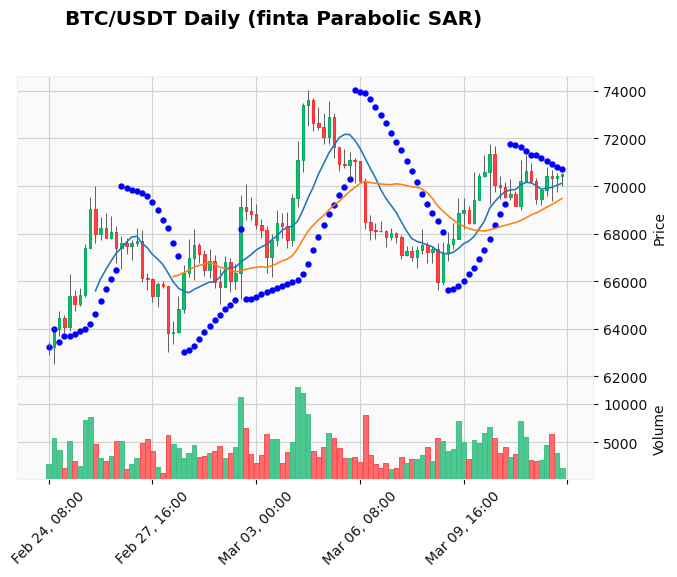

finta で Parabolic SAR を計算します...
fintaで計算したSARを描画します...


C:\Users\O-430\anaconda3\envs\bot_env\lib\site-packages\finta\finta.py:879: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hp = high[0]
C:\Users\O-430\anaconda3\envs\bot_env\lib\site-packages\finta\finta.py:880: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lp = low[0]
C:\Users\O-430\anaconda3\envs\bot_env\lib\site-packages\finta\finta.py:884: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  psar[i] = psar[i - 1] + af * (hp - psar[i - 1

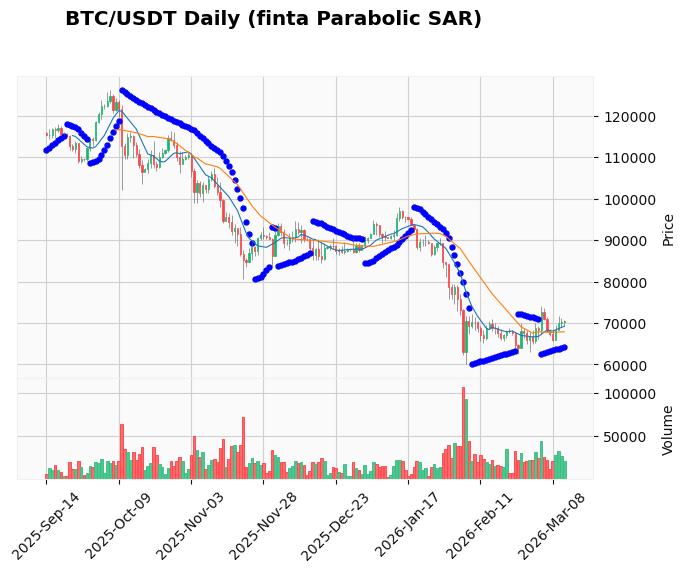

finta で ADX/DMI (14) を計算します...
DMI columns: Index(['DI+', 'DI-'], dtype='object')
fintaで計算したADXを描画します...


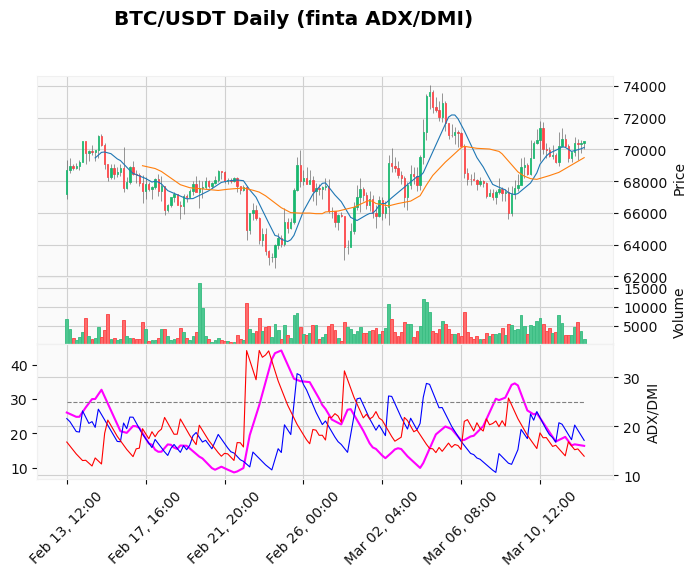

finta で ADX/DMI (14) を計算します...
DMI columns: Index(['DI+', 'DI-'], dtype='object')
fintaで計算したADXを描画します...


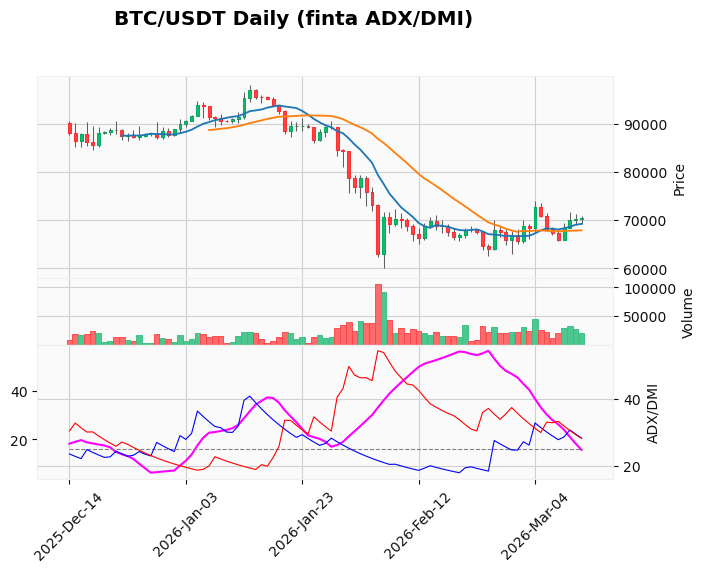

In [27]:
set_data_sar(symbol, timeframe_4h, 100, 1)
set_data_sar(symbol, timeframe_1d, 300, 6)
set_data_adx(symbol, timeframe_4h, 500, 1)
set_data_adx(symbol, timeframe_1d, 500, 3)

現在価格: $70,508.89 周辺を表示中


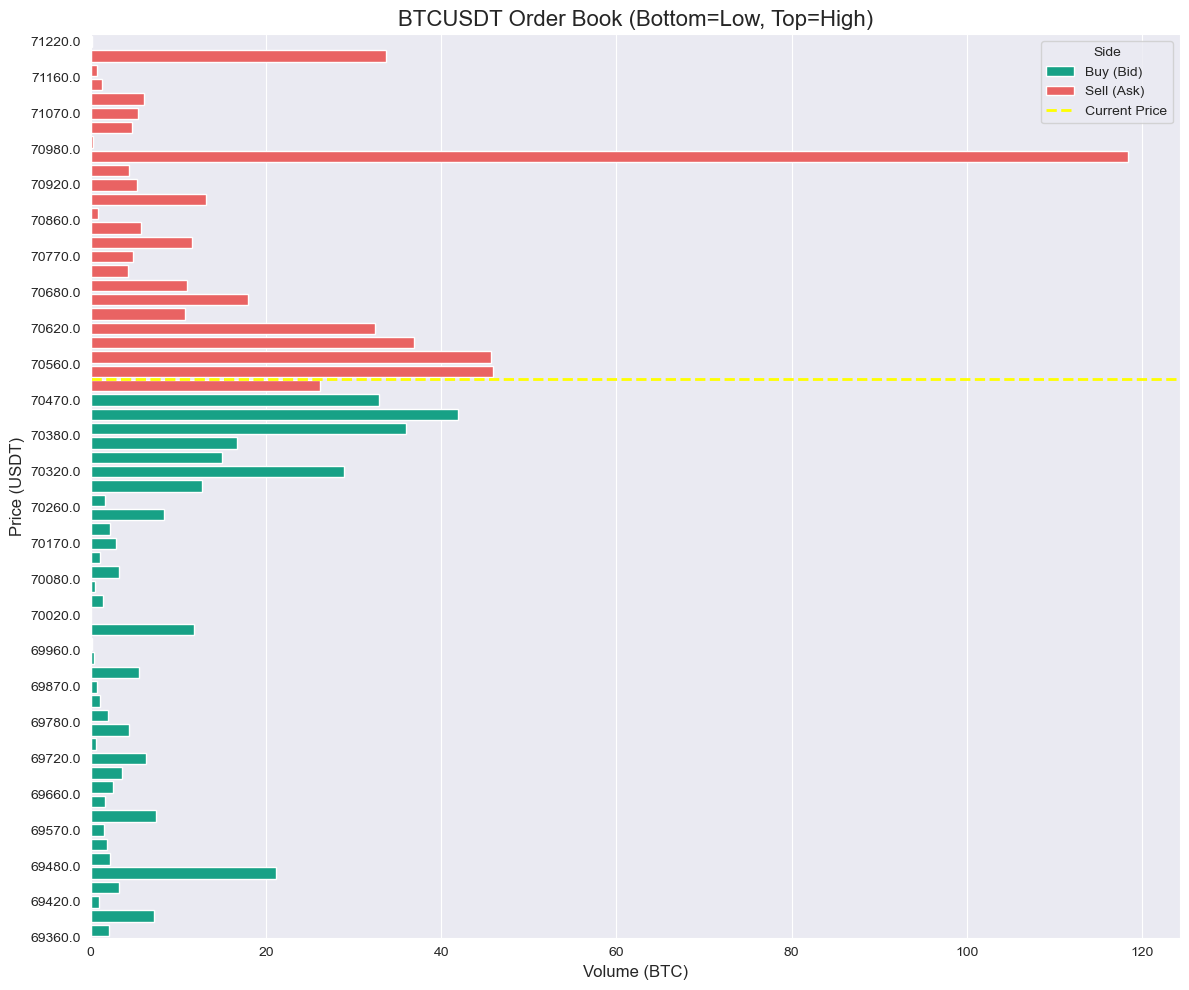

In [28]:
SYMBOL = 'BTCUSDT'     
BIN_SIZE = 30         
LIMIT = 5000       
RANGE_PERCENT = 0.05  

# ---------------------------------------------------------
# メイン処理
# ---------------------------------------------------------
if __name__ == "__main__":
    raw_data = fetch_order_book(SYMBOL, LIMIT)
    
    if raw_data:
        best_bid = float(raw_data['bids'][0][0])
        best_ask = float(raw_data['asks'][0][0])
        current_price = (best_bid + best_ask) / 2
        
        df_processed = process_data(raw_data, BIN_SIZE)
        plot_heatmap_style_depth(df_processed, current_price)

2018年からのデータを取得中... (時間がかかる場合があります)

 日付: 2026-03-12
 ★ Mayer Multiple: 0.7458

グラフを描画しています...


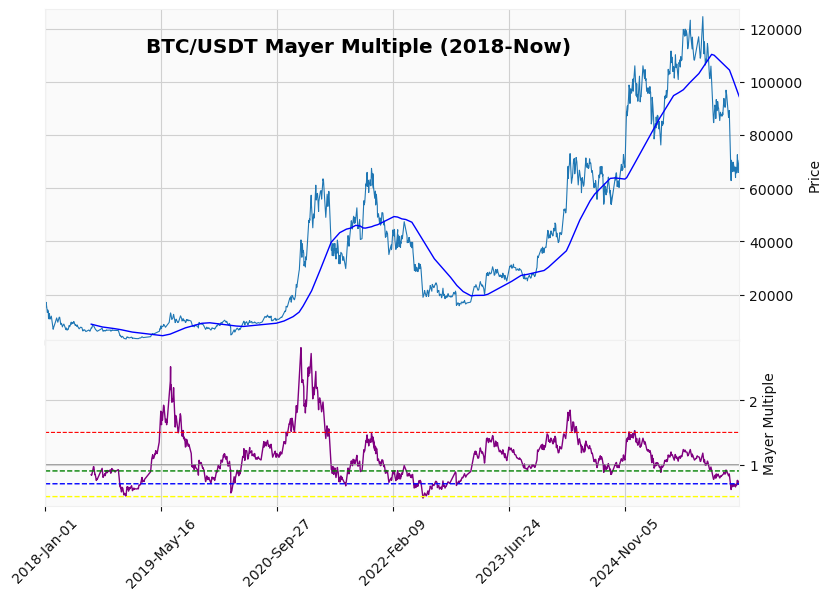

200↓1.5 Mayer 0.8↓ALL 200↑1


In [29]:
SYMBOL = symbol
TIMEFRAME = '1d'
START_YEAR = 2018  # ここを2015などに変えるとさらに遡れます

def fetch_data_from_year(symbol, timeframe, start_year):
    print(f"{start_year}年からのデータを取得中... (時間がかかる場合があります)")
    exchange = ccxt.binance()
    # 開始日時をミリ秒タイムスタンプに変換
    since = exchange.parse8601(f'{start_year}-01-01T00:00:00Z')
    
    all_ohlcv = []
    while True:
        try:
            # データ取得
            ohlcv = exchange.fetch_ohlcv(symbol, timeframe, since=since, limit=1000)
            if not ohlcv:
                break
            
            since = ohlcv[-1][0] + 1  # 次の取得開始位置を更新
            all_ohlcv += ohlcv
            
            # 現在時刻に追いついたら終了
            if ohlcv[-1][0] > exchange.milliseconds() - 86400000: 
                break
        except Exception as e:
            print(f"Error: {e}")
            break
            
    df = pd.DataFrame(all_ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    
    # 重複削除（念のため）
    df = df[~df.index.duplicated(keep='first')]
    return df

def calculate_mayer_multiple(df):
    df['SMA200'] = df['close'].rolling(window=200).mean()
    df['Mayer_Multiple'] = df['close'] / df['SMA200']
    return df

# ==========================================
# メイン処理
# ==========================================

# 1. データ取得（ループ処理版）
df = fetch_data_from_year(SYMBOL, TIMEFRAME, START_YEAR)
df = calculate_mayer_multiple(df)

# データが足りない場合
if df.empty:
    print("データが取得できませんでした。")
    exit()

# 2. 本日の数値表示
latest = df.iloc[-1]
print("\n" + "="*40)
print(f" 日付: {df.index[-1].strftime('%Y-%m-%d')}")
print(f" ★ Mayer Multiple: {latest['Mayer_Multiple']:.4f}")
print("="*40 + "\n")

# 3. グラフ表示
# 長期間見やすくするため、スタイルを調整
# ローソク足だと潰れて見にくい場合は type='line' にするのがおすすめですが、
# ここでは拡大縮小できるインタラクティブなウィンドウが出る前提でcandleにします。
# (潰れて見える場合は、mpf.plotの引数を type='line' に変更してください)

my_style = mpf.make_mpf_style(base_mpf_style='yahoo', rc={'figure.figsize':(14, 8)})

apds = [
    # パネル0: 200日線
    mpf.make_addplot(df['SMA200'], color='blue', width=1.0, panel=0),
    
    # パネル1: Mayer Multiple
    mpf.make_addplot(df['Mayer_Multiple'], color='purple', width=1.0, panel=1, ylabel='Mayer Multiple'),
    
    # パネル1: 基準線
    mpf.make_addplot([1.5]*len(df), color='red', linestyle='--', width=0.8, panel=1),
    mpf.make_addplot([1.0]*len(df), color='gray', linestyle='-', width=0.5, panel=1),
    mpf.make_addplot([0.9]*len(df), color='green', linestyle='--', width=1.0, panel=1),
    mpf.make_addplot([0.7]*len(df), color='blue', linestyle='--', width=1.0, panel=1),  # ETH=0.65
    mpf.make_addplot([0.5]*len(df), color='yellow', linestyle='--', width=1.0, panel=1),  # ETH=0.65
]

print("グラフを描画しています...")
mpf.plot(df, 
         type='line',      # 長期間なのでLineチャート推奨（candleは見づらいため）
         addplot=apds, 
         style=my_style,
         title=f'BTC/USDT Mayer Multiple ({START_YEAR}-Now)',
         volume=False,
         panel_ratios=(2, 1),
         tight_layout=True,
         warn_too_much_data=10000 # データ量警告を抑制
)
print("200↓1.5 Mayer 0.8↓ALL 200↑1")